# *Steatoda nobilis* Distribution — Exploratory Data Analysis

Correlating false widow spider occurrences with satellite-derived ALAN (VIIRS) and LST (MODIS/Landsat) across the British Isles and Western Europe.

**Data inputs:**
- **10,226** research-grade *S. nobilis* occurrence records (iNaturalist + GBIF), each with satellite-extracted values.
- **10,000** background pseudo-absence points sampled from the study area, with the same satellite variables. Because MaxEnt is a presence-only model, we have no confirmed absences. Instead, these "background" points are drawn randomly across the study area to characterise the environmental conditions *available* to the species. The model learns how conditions at known presence sites differ from the landscape as a whole. The background sample is spatially bias-corrected so that it reflects the same geographic sampling effort as the occurrence records, preventing recorder effort from being mistaken for habitat preference.
- Four predictor rasters: VIIRS nighttime radiance, MODIS day/night LST, and Landsat summer LST.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import contextily as ctx
from shapely.geometry import Point

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

DATA_DIR = "../data/processed"
CACHE_DIR = "../data/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# Set to True to force re-computation of all cached results (model, CV, importance, rasters)
FORCE_RECOMPUTE = False

SAT_COLS = [
    "viirs_avg_rad",
    "modis_lst_day_c",
    "modis_lst_night_c",
    "landsat_lst_summer_c",
]

SAT_LABELS = {
    "viirs_avg_rad": "VIIRS nighttime\nradiance (nW/cm\u00b2/sr)",
    "modis_lst_day_c": "MODIS daytime\nLST (\u00b0C)",
    "modis_lst_night_c": "MODIS nighttime\nLST (\u00b0C)",
    "landsat_lst_summer_c": "Landsat summer\nLST (\u00b0C)",
}

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
# ---------- Load data ----------
occ = pd.read_csv(f"{DATA_DIR}/sn_occurrences_with_satellite.csv")
bg  = pd.read_csv(f"{DATA_DIR}/background_points.csv")

occ["label"] = "Presence"
bg["label"]  = "Background"

# Combine into a single frame for easy plotting
shared_cols = ["longitude", "latitude"] + SAT_COLS + ["label"]
combined = pd.concat([occ[shared_cols], bg[shared_cols]], ignore_index=True)

print(f"Occurrences : {len(occ):,}")
print(f"Background  : {len(bg):,}")
print(f"Combined    : {len(combined):,}")
combined.head()

Occurrences : 10,226
Background  : 10,000
Combined    : 20,226


,longitude,latitude,viirs_avg_rad,modis_lst_day_c,modis_lst_night_c,landsat_lst_summer_c,label
0,-2.546909,51.481687,10.150000,16.878011,7.315026,29.524179,Presence
1,-0.002388,51.586408,34.313335,18.147558,7.898465,37.166872,Presence
2,-0.534053,51.331780,13.800000,15.642143,8.840674,35.727886,Presence
3,-2.729620,51.126046,9.872500,16.080404,6.584537,36.483268,Presence
4,-8.796095,39.104906,3.260000,24.846683,10.803750,42.181107,Presence


## 1. Study-area map: Occurrence vs Background points

Plot all occurrence and background points on a basemap to visualise the spatial extent of the dataset. Red points are confirmed *S. nobilis* records; grey points are pseudo-absence background locations sampled to represent available habitat across the study area (see introduction above for rationale).

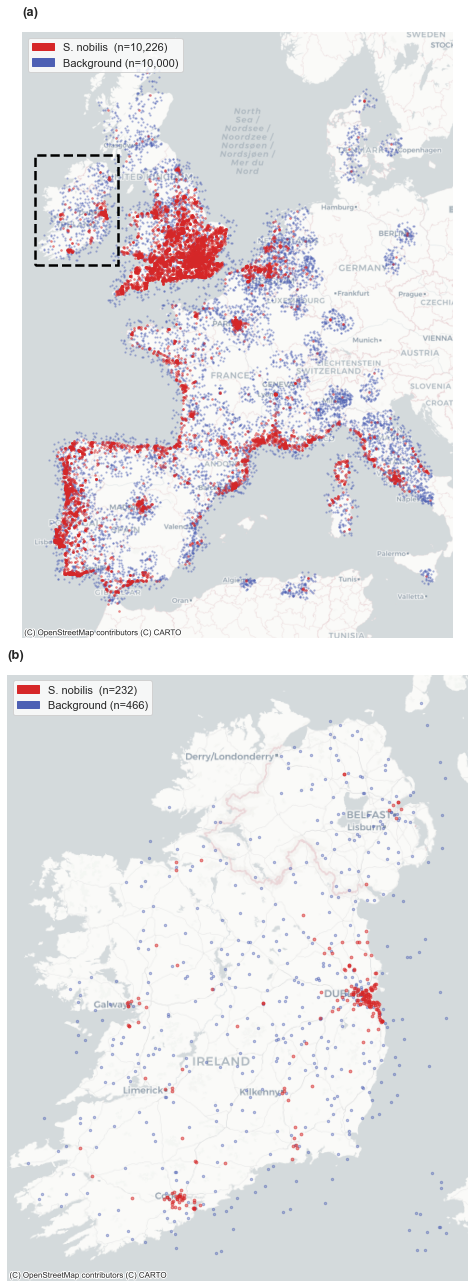

In [ ]:
# Build GeoDataFrames in EPSG:4326, then reproject to Web Mercator for basemap
gdf_occ = gpd.GeoDataFrame(
    occ, geometry=gpd.points_from_xy(occ.longitude, occ.latitude), crs="EPSG:4326"
).to_crs(epsg=3857)

gdf_bg = gpd.GeoDataFrame(
    bg, geometry=gpd.points_from_xy(bg.longitude, bg.latitude), crs="EPSG:4326"
).to_crs(epsg=3857)

# Ireland bounding box (used here and in later cells)
IRE_BOUNDS_4326 = {"west": -10.7, "east": -5.3, "south": 51.3, "north": 55.5}

# Filter points inside the Ireland bbox (needed for later cells too)
mask_occ = (
    (occ.longitude >= IRE_BOUNDS_4326["west"])
    & (occ.longitude <= IRE_BOUNDS_4326["east"])
    & (occ.latitude >= IRE_BOUNDS_4326["south"])
    & (occ.latitude <= IRE_BOUNDS_4326["north"])
)
mask_bg = (
    (bg.longitude >= IRE_BOUNDS_4326["west"])
    & (bg.longitude <= IRE_BOUNDS_4326["east"])
    & (bg.latitude >= IRE_BOUNDS_4326["south"])
    & (bg.latitude <= IRE_BOUNDS_4326["north"])
)

gdf_occ_ire = gpd.GeoDataFrame(
    occ[mask_occ],
    geometry=gpd.points_from_xy(occ.loc[mask_occ, "longitude"], occ.loc[mask_occ, "latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

gdf_bg_ire = gpd.GeoDataFrame(
    bg[mask_bg],
    geometry=gpd.points_from_xy(bg.loc[mask_bg, "longitude"], bg.loc[mask_bg, "latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

# Convert Ireland bounds to Web Mercator for the rectangle overlay
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
ire_west_m, ire_south_m = transformer.transform(IRE_BOUNDS_4326["west"], IRE_BOUNDS_4326["south"])
ire_east_m, ire_north_m = transformer.transform(IRE_BOUNDS_4326["east"], IRE_BOUNDS_4326["north"])

# ---------- Combined two-panel figure ----------
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(10, 18))

# ---- Panel (a): Study area ----
gdf_bg.plot(ax=ax_a, color="#4D60B4", markersize=2, alpha=0.3)
gdf_occ.plot(ax=ax_a, color="#d62728", markersize=3, alpha=0.4)
ctx.add_basemap(ax_a, source=ctx.providers.CartoDB.Positron, zoom=5)

# Dashed rectangle showing Ireland zoom region
rect = mpatches.Rectangle(
    (ire_west_m, ire_south_m),
    ire_east_m - ire_west_m,
    ire_north_m - ire_south_m,
    linewidth=2.5, edgecolor="black", facecolor="none", linestyle="--", zorder=10,
)
ax_a.add_patch(rect)

ax_a.set_title("(a)", fontsize=13, weight="bold", loc="left")
ax_a.legend(
    handles=[
        mpatches.Patch(color="#d62728", label=f"S. nobilis  (n={len(occ):,})"),
        mpatches.Patch(color="#4D60B4", label=f"Background (n={len(bg):,})"),
    ],
    loc="upper left", fontsize=11,
)
ax_a.set_axis_off()

# ---- Panel (b): Ireland zoom ----
gdf_bg_ire.plot(ax=ax_b, color="#4D60B4", markersize=6, alpha=0.4)
gdf_occ_ire.plot(ax=ax_b, color="#d62728", markersize=8, alpha=0.5)
ctx.add_basemap(ax_b, source=ctx.providers.CartoDB.Positron, zoom=7)

ax_b.set_title("(b)", fontsize=13, weight="bold", loc="left")
ax_b.legend(
    handles=[
        mpatches.Patch(color="#d62728", label=f"S. nobilis  (n={mask_occ.sum():,})"),
        mpatches.Patch(color="#4D60B4", label=f"Background (n={mask_bg.sum():,})"),
    ],
    loc="upper left", fontsize=11,
)
ax_b.set_axis_off()

plt.tight_layout()
plt.savefig("../outputs/study_area_map.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Ireland zoom map

The Ireland zoom is now included as panel (b) of the combined study-area figure above. The variables `IRE_BOUNDS_4326`, `mask_occ`, `mask_bg`, `gdf_occ_ire`, and `gdf_bg_ire` were defined in the cell above and are available for later use.

In [ ]:
# Ireland variables (IRE_BOUNDS_4326, mask_occ, mask_bg, gdf_occ_ire, gdf_bg_ire)
# are now defined in the combined figure cell above. Nothing to do here.
print(f"Ireland occurrences: {mask_occ.sum()}, Ireland background: {mask_bg.sum()}")

Ireland occurrences: 232, Ireland background: 466


## 3. Satellite variable distributions: Presence vs Background

Violin plots compare the distribution of each satellite predictor between presence locations and background points. If *S. nobilis* preferentially occupies warmer, more artificially-lit environments, we expect presence distributions to be shifted toward higher values relative to background — particularly for VIIRS radiance (ALAN proxy) and the LST variables.

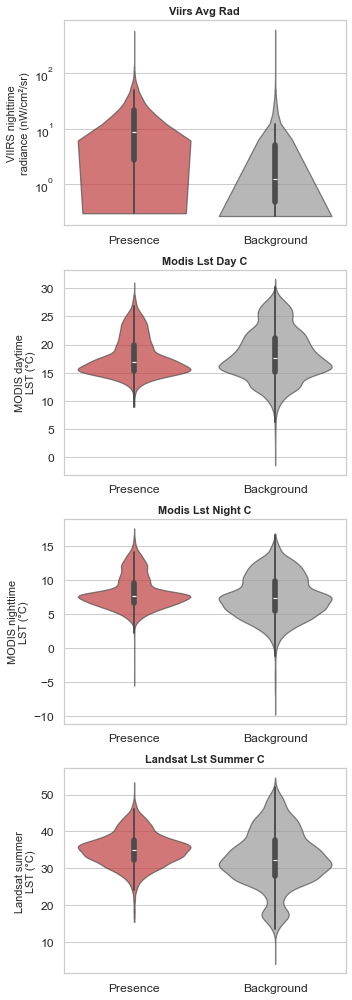

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(5, 14), sharey=False)

palette = {"Presence": "#d62728", "Background": "#999999"}

for ax, col in zip(axes, SAT_COLS):
    plot_data = combined[[col, "label"]].dropna(subset=[col])
    sns.violinplot(
        data=plot_data,
        x="label",
        y=col,
        palette=palette,
        inner="box",
        cut=0,
        ax=ax,
    )
    # Make violin bodies slightly transparent
    for pc in ax.collections:
        pc.set_alpha(0.7)
    ax.set_xlabel("")
    ax.set_ylabel(SAT_LABELS[col], fontsize=11)
    ax.set_title(col.replace("_", " ").title(), fontsize=11, weight="bold")
    if col == "viirs_avg_rad":
        ax.set_yscale("log")

plt.tight_layout()
plt.savefig("../outputs/violin_plots.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Correlation heatmap of predictor variables

Checking multicollinearity between the four predictor variables. Highly correlated predictors can inflate MaxEnt model complexity without improving predictive power. VIIRS radiance is only weakly correlated with the LST variables (r ~ 0.25–0.34), confirming it captures an independent environmental axis (anthropogenic light vs temperature). The three LST measures are more strongly intercorrelated (r = 0.65–0.85), which we should keep in mind during modelling.

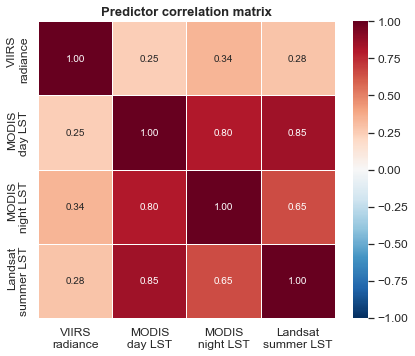

In [ ]:
# Use the combined dataset (presence + background) for correlations
corr = combined[SAT_COLS].dropna().corr()

short_labels = [
    "VIIRS\nradiance",
    "MODIS\nday LST",
    "MODIS\nnight LST",
    "Landsat\nsummer LST",
]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax,
)
ax.set_title("Predictor correlation matrix", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Summary statistics

Descriptive statistics for each satellite variable, grouped by presence/background. Key differences: median VIIRS radiance at presence sites (8.7 nW/cm^2/sr) is ~7x higher than background (1.2), and Landsat summer LST is ~3 C warmer at presence sites.

In [ ]:
summary = combined.groupby("label")[SAT_COLS].describe().T
summary

label                         Background      Presence
viirs_avg_rad        count  10000.000000  10225.000000
                     mean       6.083882     16.620848
                     std       15.490329     21.837724
                     min        0.267237      0.300000
                     25%        0.487733      2.746667
                     50%        1.223441      8.650000
                     75%        5.174399     21.630001
                     max      610.072205    579.535034
modis_lst_day_c      count   8446.000000   9993.000000
                     mean      18.221956     17.908489
                     std        4.463340      3.397759
                     min       -1.424904      8.998396
                     25%       15.234351     15.408997
                     50%       17.649745     16.923351
                     75%       21.245896     20.010206
                     max       31.650513     31.044244
modis_lst_night_c    count   8446.000000   9993.000000
                     mean       7.569154      8.261647
                     std        3.169830      2.430197
                     min       -9.758493     -5.489014
                     25%        5.388593      6.630778
                     50%        7.354499      7.717903
                     75%        9.899255      9.627500
                     max       16.809750     17.572809
landsat_lst_summer_c count   9894.000000  10199.000000
                     mean      32.617219     35.123882
                     std        7.731967      4.569373
                     min        4.007242     15.421429
                     25%       27.945180     32.255177
                     50%       32.277500     35.095552
                     75%       37.614069     37.759329
                     max       54.608250     53.366008

---

## 6. MaxEnt Species Distribution Model

### Background: what is MaxEnt?

**Maximum Entropy (MaxEnt)** is a machine-learning method for species distribution modelling that estimates the probability distribution of a species across environmental space. The core principle is to find the distribution of *maximum entropy* (i.e. closest to uniform) subject to constraints derived from the known occurrence locations. In practice, MaxEnt asks: "Given what we know about conditions where this species has been found, what is the least-biased estimate of its full distribution across the landscape?"

### Mathematical formulation

**The environmental vector $\mathbf{z}$.** Every location (pixel or sample point) in the study area is described by a vector of environmental variables measured at that site. In our case, each location has four satellite-derived measurements, so:

$$\mathbf{z} = \begin{pmatrix} z_1 \\ z_2 \\ z_3 \\ z_4 \end{pmatrix} = \begin{pmatrix} \text{VIIRS nighttime radiance (nW/cm}^2\text{/sr)} \\ \text{MODIS daytime LST (°C)} \\ \text{MODIS nighttime LST (°C)} \\ \text{Landsat summer LST (°C)} \end{pmatrix}$$

For example, a presence record in suburban Dublin might have $\mathbf{z} = (10.2,\; 16.9,\; 7.3,\; 29.5)^T$, while a rural background point in Connemara might have $\mathbf{z} = (0.5,\; 14.1,\; 5.8,\; 24.3)^T$. The model's task is to learn which regions of this 4-dimensional environmental space are associated with species presence.

**Derived features $\mathbf{h}(\mathbf{z})$.** MaxEnt does not model the raw variables directly. Instead, it constructs a vector of *derived features* $\mathbf{h}(\mathbf{z})$ that allow non-linear and interactive responses. With our configuration (linear + 10 hinge + product features across 4 variables), the feature vector is:

$$\mathbf{h}(\mathbf{z}) = \Big(\; \underbrace{z_1,\; z_2,\; z_3,\; z_4}_{\text{4 linear}},\;\; \underbrace{h_1^{(1)}(z_1),\ldots,h_{10}^{(1)}(z_1),\;\ldots,\; h_1^{(4)}(z_4),\ldots,h_{10}^{(4)}(z_4)}_{\text{40 hinge (10 per variable)}},\;\; \underbrace{z_1 z_2,\; z_1 z_3,\; z_1 z_4,\; z_2 z_3,\; z_2 z_4,\; z_3 z_4}_{\text{6 product}} \;\Big)^T$$

This gives a total of $4 + 40 + 6 = 50$ features. Each hinge feature $h_k^{(j)}(z_j)$ is a piecewise-linear function with a knot at a threshold $\tau_k$:

$$h_k^{(j)}(z_j) = \max(0,\; z_j - \tau_k)$$

These act like "soft switches" — they are zero below the threshold and increase linearly above it, allowing the model to capture abrupt environmental thresholds (e.g. suitability increasing sharply once nighttime temperature exceeds ~6°C).

**The Gibbs distribution.** MaxEnt finds the probability distribution over environmental space that has maximum entropy subject to the constraint that the expected value of each feature under the model matches its average value at the known presence sites. The solution takes the form of a Gibbs distribution:

$$f(\mathbf{z}) = \frac{1}{Z} \exp\!\Big(\sum_{i=1}^{50} \lambda_i \, h_i(\mathbf{z})\Big) = \frac{e^{\boldsymbol{\lambda} \cdot \mathbf{h}(\mathbf{z})}}{Z}$$

where $\boldsymbol{\lambda} = (\lambda_1, \ldots, \lambda_{50})^T$ are the learned feature weights and $Z = \sum_{\mathbf{z}} e^{\boldsymbol{\lambda} \cdot \mathbf{h}(\mathbf{z})}$ is a normalising constant ensuring the distribution sums to 1 over all landscape pixels. A positive weight $\lambda_i > 0$ means higher values of feature $h_i$ increase predicted suitability; a negative weight means they decrease it. The magnitude of each $\lambda_i$ reflects how strongly that feature influences the prediction.

**From raw output to suitability.** The raw Gibbs output $f(\mathbf{z})$ is a relative density, not a probability. It is transformed to the **complementary log-log (cloglog)** scale to produce a habitat suitability index on [0, 1]:

$$\text{suitability}(\mathbf{z}) = 1 - \exp\!\big(-\exp(\boldsymbol{\lambda} \cdot \mathbf{h}(\mathbf{z}) - c)\big)$$

where $c$ is a normalisation constant estimated from the data. This transformation has the convenient property that, under certain assumptions about the sampling process, the output approximates the probability of presence in a given cell.

### Feature types

MaxEnt constructs derived features from the raw environmental predictors to capture non-linear responses. We use three types here:

- **Linear** features: simple proportional relationships between a predictor and the response (e.g. suitability increases linearly with temperature).
- **Hinge** features: piecewise-linear, threshold-like responses that allow the model to capture abrupt changes (e.g. suitability drops sharply below a critical temperature). We use 10 hinge features per variable, with thresholds evenly spaced across each variable's range.
- **Product** features: pairwise interactions between variables, allowing the model to capture synergies (e.g. the effect of ALAN on suitability may depend on temperature — warm, well-lit areas may be more suitable than would be predicted from either variable alone).

### Regularisation

The **beta multiplier** ($\beta = 1.5$) is a penalty term that controls model complexity. It multiplies the L1 regularisation applied to each feature weight $\lambda_i$, adding a cost $\beta \sum_i |\lambda_i|$ to the loss function. This discourages the model from assigning large weights to features that only weakly improve fit, effectively pushing uninformative feature weights toward zero. Higher $\beta$ produces smoother, more generalised response curves at the cost of reduced training fit. We use $\beta = 1.5$ (above the default of 1.0) to err on the side of generality, following recommendations from Merow et al. (2013).

### Presence-background contrast

Unlike methods that require confirmed absences, MaxEnt is a **presence-background** method. It contrasts the environmental conditions at known occurrence sites against the conditions available across the landscape (represented by our 10,000 background points). Formally, the model maximises the log-likelihood:

$$\mathcal{L}(\boldsymbol{\lambda}) = \frac{1}{n} \sum_{i=1}^{n} \boldsymbol{\lambda} \cdot \mathbf{h}(\mathbf{z}_i) - \log\!\Big(\frac{1}{m}\sum_{j=1}^{m} e^{\boldsymbol{\lambda} \cdot \mathbf{h}(\tilde{\mathbf{z}}_j)}\Big) - \beta \sum_k |\lambda_k|$$

where $\mathbf{z}_1, \ldots, \mathbf{z}_n$ are the $n = 9{,}967$ presence locations and $\tilde{\mathbf{z}}_1, \ldots, \tilde{\mathbf{z}}_m$ are the $m = 8{,}343$ background points. The first term rewards high predicted values at presence sites; the second term penalises high predictions across the background (preventing the model from predicting high suitability everywhere); the third term is the regularisation penalty.

This is a major advantage for citizen-science data where non-detection does not imply absence.

### Why `elapid`?

We use the `elapid` Python library, which provides a scikit-learn-compatible MaxEnt implementation. Key advantages: (i) native support for geographic cross-validation via `GeographicKFold`, (ii) a familiar `.fit()` / `.predict()` API, (iii) support for raster prediction, and (iv) built-in model serialisation for caching.

### Comparison with other SDMs

MaxEnt has several advantages over alternative approaches for this dataset:

- vs. **GLMs** (generalised linear models): MaxEnt handles non-linear and threshold responses automatically through feature engineering, whereas GLMs require manual specification of polynomial or spline terms.
- vs. **Random Forests**: MaxEnt produces better-calibrated probability outputs; RF presence-background models tend to overfit to the arbitrary 0/1 labels and produce poorly calibrated pseudo-probabilities.
- vs. **BIOCLIM** (climate-envelope models): MaxEnt can capture complex, non-convex response shapes and variable interactions, while BIOCLIM is limited to rectilinear envelopes in environmental space.

Rows with any missing satellite values are dropped before fitting (primarily MODIS LST over ocean/water bodies).

In [ ]:
import elapid
from sklearn.metrics import roc_auc_score, roc_curve

# ---------- Prepare feature matrix ----------
# Presence: y=1, Background: y=0
occ_clean = occ[SAT_COLS].dropna()
bg_clean  = bg[SAT_COLS].dropna()

X = pd.concat([occ_clean, bg_clean], ignore_index=True)
y = np.concatenate([np.ones(len(occ_clean)), np.zeros(len(bg_clean))])

print(f"Presence samples (after dropping NaN): {len(occ_clean):,}")
print(f"Background samples (after dropping NaN): {len(bg_clean):,}")
print(f"Feature matrix shape: {X.shape}")

Presence samples (after dropping NaN): 9,967
Background samples (after dropping NaN): 8,343
Feature matrix shape: (18310, 4)


In [ ]:
# ---------- Fit MaxEnt on full dataset (cached) ----------
model_cache = f"{CACHE_DIR}/maxent_model.pkl"
preds_cache = f"{CACHE_DIR}/train_predictions.npz"

if not FORCE_RECOMPUTE and os.path.exists(model_cache) and os.path.exists(preds_cache):
    model = elapid.load_object(model_cache)
    _preds = np.load(preds_cache)
    y_pred_full = _preds["y_pred_full"]
    auc_full = float(_preds["auc_full"])
    print(f"Loaded cached model and predictions from {CACHE_DIR}/")
    print(f"Training AUC (full data): {auc_full:.4f}")
else:
    model = elapid.MaxentModel(
        feature_types=["linear", "hinge", "product"],
        beta_multiplier=1.5,
        n_hinge_features=10,
        n_cpus=4,
    )
    model.fit(X, y)

    # Full-data training AUC
    y_pred_full = model.predict(X)
    auc_full = roc_auc_score(y, y_pred_full)
    print(f"Training AUC (full data): {auc_full:.4f}")

    # Save to cache
    elapid.save_object(model, model_cache)
    np.savez(preds_cache, y_pred_full=y_pred_full, auc_full=auc_full)
    print(f"Saved model and predictions to {CACHE_DIR}/")

Loaded cached model and predictions from ../data/cache/
Training AUC (full data): 0.7972


### 6.1 Spatial cross-validation

**Why spatial CV is necessary.** Standard random k-fold cross-validation produces inflated AUC estimates for spatial data because nearby training and test points share environmental autocorrelation — they tend to have similar satellite values simply because they are geographically close. A model that memorises local environmental patterns will score well on randomly held-out points that happen to lie near training data, even if it has poor transferability to new regions. Spatial CV eliminates this optimistic bias by ensuring that training and test sets are geographically separated.

**How `GeographicKFold` works.** The `elapid.GeographicKFold` splitter partitions the study area into *k* spatially contiguous blocks using k-means clustering on the point coordinates. Each fold trains on k-1 blocks and evaluates on the held-out block, guaranteeing a spatial buffer between training and test sets. We use k=4 folds, producing four geographically distinct evaluation regions across our Western European study area.

**What AUC means in a presence-background context.** In a standard binary classification, AUC measures the probability that a randomly chosen positive example is ranked higher than a randomly chosen negative. In the presence-background setting, there are no true negatives — the "negative" class is simply a sample of the landscape. Here, AUC measures the model's ability to rank known presence sites higher than random background locations. An AUC of 0.5 means the model cannot distinguish presence conditions from background; values above 0.7 are generally considered useful discrimination for presence-background models.

The gap between training AUC and spatial CV AUC quantifies how much spatial autocorrelation inflates apparent performance.

In [ ]:
# ---------- Geographic k-fold cross-validation (cached) ----------
cv_cache = f"{CACHE_DIR}/spatial_cv_results.pkl"

if not FORCE_RECOMPUTE and os.path.exists(cv_cache):
    _cv = elapid.load_object(cv_cache)
    cv_aucs = _cv["cv_aucs"]
    cv_fpr_list = _cv["cv_fpr_list"]
    cv_tpr_list = _cv["cv_tpr_list"]
    mean_auc = _cv["mean_auc"]
    std_auc = _cv["std_auc"]
    print(f"Loaded cached spatial CV results from {cv_cache}")
    for i, auc_i in enumerate(cv_aucs):
        print(f"  Fold {i + 1}/{len(cv_aucs)}:  test AUC = {auc_i:.4f}")
    print(f"\nSpatial CV AUC: {mean_auc:.4f} +/- {std_auc:.4f}")
else:
    # Build a GeoDataFrame of ALL points (presence + background) in the same order as X/y
    occ_coords = occ.loc[occ_clean.index, ["longitude", "latitude"]].reset_index(drop=True)
    bg_coords  = bg.loc[bg_clean.index, ["longitude", "latitude"]].reset_index(drop=True)
    all_coords = pd.concat([occ_coords, bg_coords], ignore_index=True)

    all_points = gpd.GeoDataFrame(
        all_coords,
        geometry=gpd.points_from_xy(all_coords.longitude, all_coords.latitude),
        crs="EPSG:4326",
    )

    N_FOLDS = 4
    gkf = elapid.GeographicKFold(n_splits=N_FOLDS, random_state=42)

    cv_aucs = []
    cv_fpr_list, cv_tpr_list = [], []

    for fold_i, (train_idx, test_idx) in enumerate(gkf.split(all_points)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        m = elapid.MaxentModel(
            feature_types=["linear", "hinge", "product"],
            beta_multiplier=1.5,
            n_hinge_features=10,
            n_cpus=4,
        )
        m.fit(X_train, y_train)
        y_prob = m.predict(X_test)

        auc_i = roc_auc_score(y_test, y_prob)
        cv_aucs.append(auc_i)

        fpr_i, tpr_i, _ = roc_curve(y_test, y_prob)
        cv_fpr_list.append(fpr_i)
        cv_tpr_list.append(tpr_i)

        print(f"  Fold {fold_i + 1}/{N_FOLDS}:  test AUC = {auc_i:.4f}  "
              f"(train {len(train_idx):,} / test {len(test_idx):,})")

    mean_auc = np.mean(cv_aucs)
    std_auc  = np.std(cv_aucs)
    print(f"\nSpatial CV AUC: {mean_auc:.4f} +/- {std_auc:.4f}")

    # Save to cache
    elapid.save_object({
        "cv_aucs": cv_aucs,
        "cv_fpr_list": cv_fpr_list,
        "cv_tpr_list": cv_tpr_list,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
    }, cv_cache)
    print(f"Saved spatial CV results to {cv_cache}")

Loaded cached spatial CV results from ../data/cache/spatial_cv_results.pkl
  Fold 1/4:  test AUC = 0.6495
  Fold 2/4:  test AUC = 0.6790
  Fold 3/4:  test AUC = 0.7412
  Fold 4/4:  test AUC = 0.6880

Spatial CV AUC: 0.6894 +/- 0.0331


### 6.2 ROC curves

ROC curves for each spatial CV fold, plus the full-data training curve. The gap between the training curve and the CV fold curves indicates how much spatial autocorrelation inflates apparent performance.

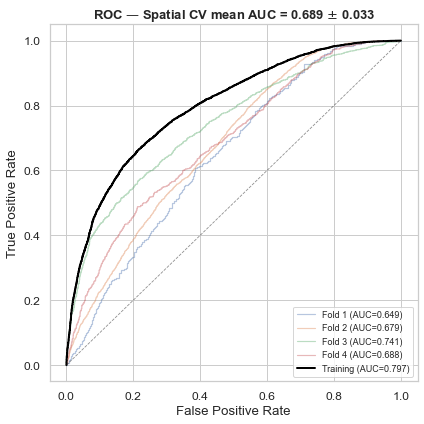

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

# Per-fold ROC curves
for i, (fpr_i, tpr_i) in enumerate(zip(cv_fpr_list, cv_tpr_list)):
    ax.plot(fpr_i, tpr_i, alpha=0.4, lw=1.2, label=f"Fold {i+1} (AUC={cv_aucs[i]:.3f})")

# Full-data training ROC
fpr_full, tpr_full, _ = roc_curve(y, y_pred_full)
ax.plot(fpr_full, tpr_full, color="black", lw=2,
        label=f"Training (AUC={auc_full:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC — Spatial CV mean AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f}",
             fontsize=13, weight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.3 Permutation variable importance

**What permutation importance measures.** For each predictor variable, we randomly shuffle its values across all samples, breaking any learned relationship with the response, and then re-score the model. The drop in AUC relative to the unshuffled baseline quantifies how much the model relies on that variable. A large AUC drop means the model's predictions deteriorate substantially without that variable's signal — it is important. A near-zero drop means the variable contributes little beyond what the other predictors already capture.

**Why permutation importance over other metrics.** MaxEnt's built-in variable contribution metrics (percent contribution and permutation importance computed during training) are calculated on the training data and can be influenced by the order in which variables enter the model. Our approach instead evaluates importance on the full dataset *after* fitting, giving a more stable and interpretable assessment. Compared to methods like SHAP values, permutation importance is model-agnostic, computationally straightforward, and directly tied to a meaningful performance metric (AUC).

We repeat the permutation 10 times per variable to obtain stable mean and standard deviation estimates.

In [ ]:
# ---------- Permutation importance (cached) ----------
imp_cache = f"{CACHE_DIR}/permutation_importance.pkl"

if not FORCE_RECOMPUTE and os.path.exists(imp_cache):
    imp_df = elapid.load_object(imp_cache)
    print(f"Loaded cached permutation importance from {imp_cache}")
    print(imp_df.to_string(index=False))
else:
    rng = np.random.RandomState(42)
    n_repeats = 10
    baseline_auc = auc_full

    importance_scores = {col: [] for col in SAT_COLS}

    for col in SAT_COLS:
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)
            y_perm_pred = model.predict(X_perm)
            auc_perm = roc_auc_score(y, y_perm_pred)
            importance_scores[col].append(baseline_auc - auc_perm)

    imp_df = pd.DataFrame({
        "Variable": SAT_COLS,
        "Mean AUC drop": [np.mean(importance_scores[c]) for c in SAT_COLS],
        "Std":           [np.std(importance_scores[c]) for c in SAT_COLS],
    }).sort_values("Mean AUC drop", ascending=False)

    print(imp_df.to_string(index=False))

    # Save to cache
    elapid.save_object(imp_df, imp_cache)
    print(f"\nSaved permutation importance to {imp_cache}")

Loaded cached permutation importance from ../data/cache/permutation_importance.pkl
            Variable  Mean AUC drop      Std
     modis_lst_day_c       0.199641 0.002113
landsat_lst_summer_c       0.151769 0.002546
   modis_lst_night_c       0.084844 0.003082
       viirs_avg_rad       0.058895 0.001961


In [ ]:
# ---------- Variable importance (standalone figure) ----------
# Readable y-axis labels for the bar chart
IMP_LABELS = {
    "viirs_avg_rad": "VIIRS nighttime radiance",
    "modis_lst_day_c": "MODIS daytime LST",
    "modis_lst_night_c": "MODIS nighttime LST",
    "landsat_lst_summer_c": "Landsat summer LST",
}
imp_labels = [IMP_LABELS.get(v, v) for v in imp_df["Variable"]]

fig_imp, ax_imp = plt.subplots(figsize=(6, 3.5))
colors = ["#d62728" if v == imp_df["Variable"].iloc[0] else "#4878d0" for v in imp_df["Variable"]]
ax_imp.barh(imp_labels, imp_df["Mean AUC drop"], xerr=imp_df["Std"],
            color=colors, edgecolor="white", capsize=3, alpha=0.8)
ax_imp.set_xlabel("Mean AUC drop (permutation importance)", fontsize=10)
ax_imp.set_title("Permutation variable importance", fontsize=11, weight="bold")
ax_imp.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/variable_importance.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------- Response curves (standalone figure) ----------
import matplotlib.gridspec as gridspec

fig_rc = plt.figure(figsize=(6, 18))
gs = gridspec.GridSpec(4, 1, hspace=0.4)

medians = X.median()
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for i, col in enumerate(SAT_COLS):
    ax = fig_rc.add_subplot(gs[i])
    grid = np.linspace(X[col].quantile(0.01), X[col].quantile(0.99), 200)
    X_synth = pd.DataFrame(
        np.tile(medians.values, (len(grid), 1)),
        columns=SAT_COLS,
    )
    X_synth[col] = grid
    y_synth = model.predict(X_synth)

    ax.plot(grid, y_synth, color="#d62728", lw=2)
    ax.fill_between(grid, 0, y_synth, alpha=0.15, color="#d62728")
    ax.set_xlabel(SAT_LABELS[col].replace("\n", " "), fontsize=10)
    ax.set_ylabel("Predicted suitability", fontsize=10)
    ax.set_title(f"{panel_labels[i]} {col.replace('_', ' ').title()}", fontsize=11, weight="bold", loc="left")
    ax.set_ylim(0, None)

plt.savefig("../outputs/response_curves.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.4 Marginal response curves

**What marginal response curves show.** Each panel is a **partial dependence plot**: it shows the model's predicted habitat suitability as one predictor varies across its observed range while all other predictors are held fixed at their median values. This isolates each variable's marginal effect, revealing whether the relationship is linear, threshold-like (hinge), unimodal, or more complex.

**How to interpret them.** A rising curve means suitability increases with higher values of that predictor; a flat curve means the variable has little marginal effect in that range. A sharp inflection indicates a hinge feature is active — for example, suitability may be uniformly low below a critical temperature threshold, then rise steeply above it. Because other variables are held at their medians, these curves show the *typical* response shape. In regions where other variables deviate substantially from their medians, the actual predicted suitability may differ due to product (interaction) features.

In [ ]:
# Response curves are now included in the combined model_diagnostics figure above.
# This cell is kept as a placeholder.
print("Response curves generated in combined figure above.")

Response curves generated in combined figure above.


---

## 7. Prediction surfaces

Apply the trained MaxEnt model to the full raster stacks to produce continuous habitat suitability maps. Each pixel's four band values are fed through the model to get a cloglog-transformed probability of presence. The result is a suitability surface ranging from 0 (unsuitable) to 1 (highly suitable), saved as a GeoTIFF for use in GIS.

In [ ]:
import rasterio
from rasterio.transform import from_bounds

RASTER_DIR = "../data/processed/rasters"
OUTPUT_DIR = "../outputs"

def predict_raster(stack_path, output_path, mdl):
    """Apply a fitted MaxEnt model to a 4-band raster stack."""
    with rasterio.open(stack_path) as src:
        data = src.read()  # (4, H, W)
        profile = src.profile.copy()
        H, W = src.height, src.width

    # Reshape to (n_pixels, 4) — band order matches SAT_COLS
    flat = data.reshape(4, -1).T  # (H*W, 4)
    df = pd.DataFrame(flat, columns=SAT_COLS)

    # Mask: pixels where ANY band is NaN
    valid = df.notna().all(axis=1)

    suitability = np.full(len(df), np.nan)
    if valid.sum() > 0:
        suitability[valid.values] = mdl.predict(df.loc[valid])

    suit_grid = suitability.reshape(H, W)

    # Write single-band output GeoTIFF
    profile.update(count=1, dtype="float32", nodata=np.nan, compress="deflate")
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(suit_grid.astype(np.float32), 1)
        dst.set_band_description(1, "habitat_suitability")

    pct_valid = 100 * valid.sum() / len(df)
    print(f"  {output_path}")
    print(f"    {H} x {W} pixels, {valid.sum():,} valid ({pct_valid:.1f}%)")
    print(f"    Suitability range: {np.nanmin(suit_grid):.4f} – {np.nanmax(suit_grid):.4f}")
    return suit_grid

def load_suitability_tif(output_path):
    """Load a previously saved suitability GeoTIFF as a numpy array."""
    with rasterio.open(output_path) as src:
        suit_grid = src.read(1)
        H, W = src.height, src.width
    # Replace nodata with NaN
    suit_grid = suit_grid.astype(np.float32)
    suit_grid[suit_grid == src.nodata] = np.nan if src.nodata is not None else suit_grid
    pct_valid = 100 * np.count_nonzero(~np.isnan(suit_grid)) / suit_grid.size
    print(f"  Loaded {output_path}")
    print(f"    {H} x {W} pixels, {np.count_nonzero(~np.isnan(suit_grid)):,} valid ({pct_valid:.1f}%)")
    print(f"    Suitability range: {np.nanmin(suit_grid):.4f} – {np.nanmax(suit_grid):.4f}")
    return suit_grid

# ---------- Study area (1 km) ----------
study_tif = f"{OUTPUT_DIR}/suitability_study_area_1km.tif"
if not FORCE_RECOMPUTE and os.path.exists(study_tif):
    print("Loading cached study area prediction...")
    suit_study = load_suitability_tif(study_tif)
else:
    print("Predicting study area (1 km)...")
    suit_study = predict_raster(
        f"{RASTER_DIR}/study_area_stack_1km.tif", study_tif, model,
    )

# ---------- Ireland (500 m) ----------
ireland_tif = f"{OUTPUT_DIR}/suitability_ireland_500m.tif"
if not FORCE_RECOMPUTE and os.path.exists(ireland_tif):
    print("\nLoading cached Ireland prediction...")
    suit_ireland = load_suitability_tif(ireland_tif)
else:
    print("\nPredicting Ireland (500 m)...")
    suit_ireland = predict_raster(
        f"{RASTER_DIR}/ireland_stack_500m.tif", ireland_tif, model,
    )

Loading cached study area prediction...
  Loaded ../outputs/suitability_study_area_1km.tif
    2778 x 3000 pixels, 3,736,634 valid (44.8%)
    Suitability range: 0.0000 – 1.0000

Loading cached Ireland prediction...
  Loaded ../outputs/suitability_ireland_500m.tif
    933 x 1111 pixels, 532,160 valid (51.3%)
    Suitability range: 0.0022 – 1.0000


### 7.1 Suitability maps: study area and Ireland

Combined two-panel figure showing predicted habitat suitability: (a) Western Europe at 1 km resolution with occurrence records overlaid, and (b) Ireland at 500 m resolution with Irish occurrences overlaid.

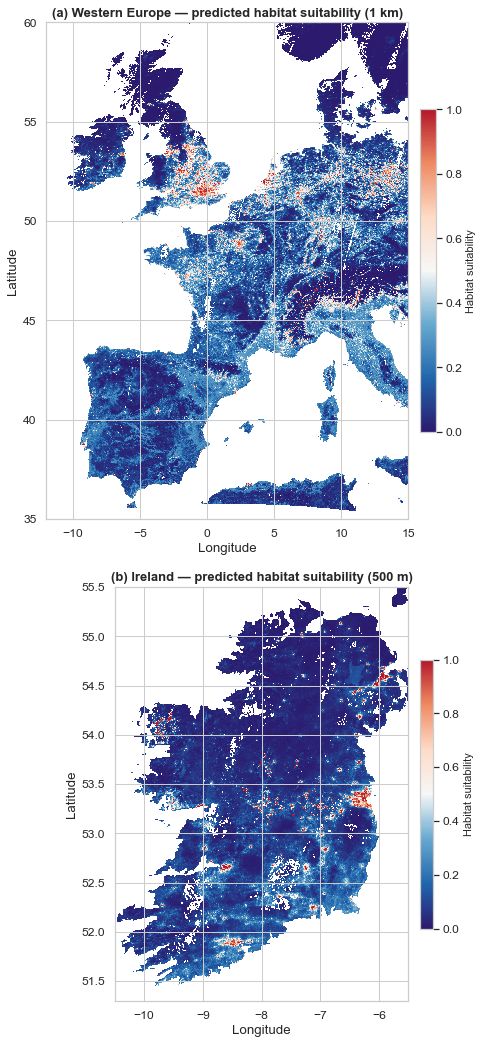

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

# Custom suitability colourmap: dark blue -> yellow -> red
suit_cmap = LinearSegmentedColormap.from_list(
    "suitability", ["#2b1a6e", "#2166ac", "#67a9cf", "#f7f7f7", "#fddbc7", "#ef8a62", "#b2182b"]
)

# ---------- Read raster bounds (needed here and by later cells) ----------
with rasterio.open(f"{RASTER_DIR}/study_area_stack_1km.tif") as src:
    study_bounds = src.bounds

study_centre_lat = (study_bounds.bottom + study_bounds.top) / 2
study_aspect = 1 / np.cos(np.radians(study_centre_lat))

with rasterio.open(f"{RASTER_DIR}/ireland_stack_500m.tif") as src:
    ire_bounds = src.bounds

ire_centre_lat = (ire_bounds.bottom + ire_bounds.top) / 2
ire_aspect = 1 / np.cos(np.radians(ire_centre_lat))

occ_ire = occ[mask_occ]

# ---------- Combined two-panel suitability figure ----------
fig = plt.figure(figsize=(10, 18))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1], hspace=0.15)

# ---- Panel (a): Study area (1 km) ----
ax_a = fig.add_subplot(gs[0])
im_a = ax_a.imshow(
    suit_study,
    extent=[study_bounds.left, study_bounds.right, study_bounds.bottom, study_bounds.top],
    origin="upper", cmap=suit_cmap, vmin=0, vmax=1,
    interpolation="nearest", aspect=study_aspect,
)
ax_a.set_xlabel("Longitude")
ax_a.set_ylabel("Latitude")
ax_a.set_title("(a) Western Europe — predicted habitat suitability (1 km)",
               fontsize=13, weight="bold")
cbar_a = plt.colorbar(im_a, ax=ax_a, shrink=0.65, pad=0.02)
cbar_a.set_label("Habitat suitability", fontsize=11)

# ---- Panel (b): Ireland (500 m) ----
ax_b = fig.add_subplot(gs[1])
im_b = ax_b.imshow(
    suit_ireland,
    extent=[ire_bounds.left, ire_bounds.right, ire_bounds.bottom, ire_bounds.top],
    origin="upper", cmap=suit_cmap, vmin=0, vmax=1,
    interpolation="nearest", aspect=ire_aspect,
)
ax_b.set_xlabel("Longitude")
ax_b.set_ylabel("Latitude")
ax_b.set_title("(b) Ireland — predicted habitat suitability (500 m)",
               fontsize=13, weight="bold")
cbar_b = plt.colorbar(im_b, ax=ax_b, shrink=0.65, pad=0.02)
cbar_b.set_label("Habitat suitability", fontsize=11)

plt.savefig(f"{OUTPUT_DIR}/suitability_map_combined.png", dpi=250, bbox_inches="tight")
plt.show()

### 7.2 Ireland suitability map

The Ireland suitability map is now included as panel (b) of the combined figure above. The variables `ire_bounds`, `ire_aspect`, and `occ_ire` were defined in the cell above and are available for later use.

In [ ]:
# Ireland suitability map is now part of the combined figure in cell-28.
# Variables ire_bounds, ire_aspect, occ_ire are defined there.
print(f"Ireland bounds: {ire_bounds}")
print(f"Ireland occurrences for overlay: {len(occ_ire)}")

Ireland bounds: BoundingBox(left=-10.5, bottom=51.3, right=-5.5, top=55.5)
Ireland occurrences for overlay: 232


---

## 8. Publication composite figure

A single multi-panel figure combining the key results for journal submission:
- **(a)** Study-area suitability map with occurrence overlay
- **(b)** Ireland suitability inset
- **(c)** Variable importance bar chart
- **(d)** Marginal response curves

In [ ]:
fig = plt.figure(figsize=(16, 16))

# Layout: top row = two maps, bottom row = importance + response curves
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], hspace=0.28, wspace=0.25)

# ---- (a) Study-area suitability ----
ax_a = fig.add_subplot(gs[0, 0])
im_a = ax_a.imshow(
    suit_study,
    extent=[study_bounds.left, study_bounds.right, study_bounds.bottom, study_bounds.top],
    origin="upper", cmap=suit_cmap, vmin=0, vmax=1, interpolation="nearest",
    aspect=study_aspect,
)
ax_a.set_xlabel("Longitude", fontsize=10)
ax_a.set_ylabel("Latitude", fontsize=10)
ax_a.set_title("(a) Study-area habitat suitability", fontsize=12, weight="bold")
cbar_a = plt.colorbar(im_a, ax=ax_a, shrink=0.6, pad=0.02)
cbar_a.set_label("Suitability", fontsize=10)

# ---- (b) Ireland suitability ----
ax_b = fig.add_subplot(gs[0, 1])
im_b = ax_b.imshow(
    suit_ireland,
    extent=[ire_bounds.left, ire_bounds.right, ire_bounds.bottom, ire_bounds.top],
    origin="upper", cmap=suit_cmap, vmin=0, vmax=1, interpolation="nearest",
    aspect=ire_aspect,
)
ax_b.set_xlabel("Longitude", fontsize=10)
ax_b.set_ylabel("Latitude", fontsize=10)
ax_b.set_title("(b) Ireland suitability (500 m)", fontsize=12, weight="bold")
cbar_b = plt.colorbar(im_b, ax=ax_b, shrink=0.6, pad=0.02)
cbar_b.set_label("Suitability", fontsize=10)

# ---- (c) Variable importance ----
ax_c = fig.add_subplot(gs[1, 0])
colors_c = ["#d62728" if v == imp_df["Variable"].iloc[0] else "#4878d0" for v in imp_df["Variable"]]
imp_labels_c = [IMP_LABELS.get(v, v) for v in imp_df["Variable"]]
ax_c.barh(imp_labels_c, imp_df["Mean AUC drop"], xerr=imp_df["Std"],
           color=colors_c, edgecolor="white", capsize=3, alpha=0.8)
ax_c.set_xlabel("Mean AUC drop", fontsize=10)
ax_c.set_title("(c) Permutation variable importance", fontsize=12, weight="bold")
ax_c.invert_yaxis()

# ---- (d) Response curves ----
ax_d = fig.add_subplot(gs[1, 1])
medians_d = X.median()
line_colors = ["#d62728", "#2166ac", "#67a9cf", "#f4a582"]
for col, lc in zip(SAT_COLS, line_colors):
    grid = np.linspace(X[col].quantile(0.01), X[col].quantile(0.99), 200)
    X_synth = pd.DataFrame(np.tile(medians_d.values, (len(grid), 1)), columns=SAT_COLS)
    X_synth[col] = grid
    y_synth = model.predict(X_synth)
    label = IMP_LABELS.get(col, col.replace("_", " "))
    ax_d.plot(grid, y_synth, lw=2, color=lc, label=label)

ax_d.set_xlabel("Predictor value (standardised range)", fontsize=10)
ax_d.set_ylabel("Predicted suitability", fontsize=10)
ax_d.set_title("(d) Marginal response curves", fontsize=12, weight="bold")
ax_d.legend(fontsize=8, loc="center right")
ax_d.set_ylim(0, None)

plt.savefig(f"{OUTPUT_DIR}/figures/composite_figure.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/figures/composite_figure.pdf", bbox_inches="tight")
plt.show()

print(f"\nSaved to {OUTPUT_DIR}/figures/composite_figure.png  and  .pdf")

---

## 9. Temporal analysis — expansion of *S. nobilis* in Ireland

*S. nobilis* was first confirmed in Ireland in 1999, but citizen-science records in our dataset begin in 2017. This section examines the rate of geographic spread across Ireland over 2017–2025, fits a logistic colonisation model to the observed expansion, and combines it with the MaxEnt suitability surface to identify high-suitability areas not yet colonised and estimate when they may be reached.

In [ ]:
# ---------- Prepare temporal data ----------
occ["observed_on"] = pd.to_datetime(occ["observed_on"])
occ["year"] = occ["observed_on"].dt.year

# Ireland subset (reuse bounds from earlier)
ire = occ[mask_occ].copy()

# Assign each record to a ~10 km grid cell (0.1 deg)
ire["grid_cell"] = (
    (ire.latitude * 10).round().astype(int).astype(str)
    + "_"
    + (ire.longitude * 10).round().astype(int).astype(str)
)

# Annual counts
yearly_counts_ire = ire.groupby("year").size().rename("Ireland")
yearly_counts_all = occ.groupby("year").size().rename("All records")
yearly = pd.concat([yearly_counts_all, yearly_counts_ire], axis=1).fillna(0).astype(int)

# Cumulative unique grid cells colonised through each year
years_full = sorted(ire.year.unique())
cum_cells = []
for yr in years_full:
    n = ire[ire.year <= yr]["grid_cell"].nunique()
    cum_cells.append({"year": yr, "cum_grid_cells": n})
cum_cells = pd.DataFrame(cum_cells)

# Exclude 2026 (incomplete year) from trend fitting
cum_cells_fit = cum_cells[cum_cells.year <= 2025].copy()

print("Annual sighting counts:")
print(yearly.to_string())
print(f"\nIreland: {ire.grid_cell.nunique()} unique ~10 km grid cells colonised by 2025")

Annual sighting counts:
      All records  Ireland
year                      
2017           91        2
2018          174        6
2019          450       23
2020          917       31
2021         1080       22
2022         1336       26
2023         1479       29
2024         1842       42
2025         2705       44
2026          152        7

Ireland: 86 unique ~10 km grid cells colonised by 2025


### 9.1 Annual sighting trends

Annual sighting counts are prepared here and plotted in the combined temporal figure after the logistic growth model is fitted (Section 9.3).

In [ ]:
# The annual sightings bar chart is now part of the combined temporal figure
# generated after the logistic growth fitting in the cell below cell-40.
# Data variables (yearly, cum_cells_fit) are defined in cell-34.
print("Annual sightings will be plotted in combined temporal figure below.")

Annual sightings will be plotted in combined temporal figure below.


### 9.2 Geographic spread in Ireland over time

Maps showing the cumulative expansion of *S. nobilis* sighting locations in Ireland across three time periods, overlaid on the MaxEnt suitability surface. This illustrates how the species has radiated outward from Dublin and the east coast into new areas with high predicted suitability.

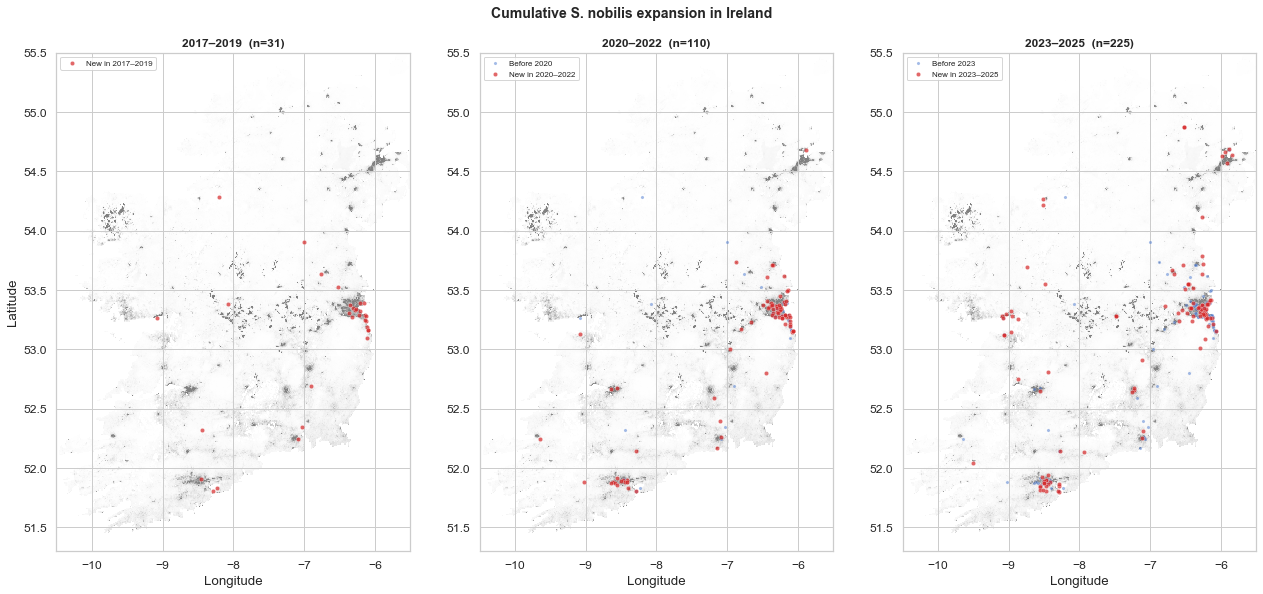

In [ ]:
# ---------- Temporal expansion maps ----------
time_bins = [
    ("2017–2019", 2017, 2019),
    ("2020–2022", 2020, 2022),
    ("2023–2025", 2023, 2025),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (label, yr_start, yr_end) in zip(axes, time_bins):
    # Suitability background
    ax.imshow(
        suit_ireland,
        extent=[ire_bounds.left, ire_bounds.right, ire_bounds.bottom, ire_bounds.top],
        origin="upper", cmap="Greys", vmin=0, vmax=1, interpolation="nearest",
        aspect=ire_aspect, alpha=0.5,
    )
    # Cumulative points up to yr_end
    sub = ire[ire.year <= yr_end]
    # Colour new arrivals differently from earlier ones
    old = sub[sub.year < yr_start]
    new = sub[(sub.year >= yr_start) & (sub.year <= yr_end)]

    if len(old) > 0:
        ax.scatter(old.longitude, old.latitude, s=10, c="#4878d0", alpha=0.5,
                   edgecolors="white", linewidths=0.2, label=f"Before {yr_start}", rasterized=True)
    ax.scatter(new.longitude, new.latitude, s=18, c="#d62728", alpha=0.7,
               edgecolors="white", linewidths=0.3, label=f"New in {label}", zorder=5, rasterized=True)

    ax.set_xlim(ire_bounds.left, ire_bounds.right)
    ax.set_ylim(ire_bounds.bottom, ire_bounds.top)
    ax.set_title(f"{label}  (n={len(sub)})", fontsize=12, weight="bold")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_xlabel("Longitude")
    if ax == axes[0]:
        ax.set_ylabel("Latitude")

fig.suptitle("Cumulative S. nobilis expansion in Ireland", fontsize=14, weight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ireland_temporal_expansion.png", dpi=200, bbox_inches="tight")
plt.show()

### 9.3 Colonisation rate and logistic growth projection

The cumulative number of unique ~10 km grid cells with at least one *S. nobilis* record follows a roughly logistic (S-shaped) trajectory — rapid initial discovery of new cells, expected to saturate as available habitat fills. We fit a logistic growth model to estimate the carrying capacity (K) — the total number of grid cells the species may eventually occupy in Ireland — and project forward to identify when key thresholds (e.g. 75%, 90% of K) might be reached.

An important caveat: rising citizen-science effort inflates detection over time, so part of the apparent expansion reflects improved coverage rather than genuine spread. The projection should be interpreted as an upper-bound scenario.

In [ ]:
from scipy.optimize import curve_fit

# ---------- Logistic growth model ----------
def logistic(t, K, r, t0):
    """Logistic growth: K / (1 + exp(-r * (t - t0)))"""
    return K / (1 + np.exp(-r * (t - t0)))

# Count how many Ireland grid cells have suitability >= 0.3 (plausible habitat)
with rasterio.open(f"{RASTER_DIR}/ireland_stack_500m.tif") as src:
    ire_res = src.res

lat_bins = np.arange(ire_bounds.bottom, ire_bounds.top, 0.1)
lon_bins = np.arange(ire_bounds.left, ire_bounds.right, 0.1)

suitable_cells = 0
total_land_cells = 0
for lat_c in lat_bins + 0.05:
    for lon_c in lon_bins + 0.05:
        row = int((ire_bounds.top - lat_c) / (ire_bounds.top - ire_bounds.bottom) * suit_ireland.shape[0])
        col = int((lon_c - ire_bounds.left) / (ire_bounds.right - ire_bounds.left) * suit_ireland.shape[1])
        if 0 <= row < suit_ireland.shape[0] and 0 <= col < suit_ireland.shape[1]:
            val = suit_ireland[row, col]
            if not np.isnan(val):
                total_land_cells += 1
                if val >= 0.3:
                    suitable_cells += 1

print(f"Ireland ~10 km grid: {total_land_cells} land cells, {suitable_cells} with suitability >= 0.3")

# Fit logistic model to cumulative cells (2017-2025)
t_data = cum_cells_fit["year"].values.astype(float)
y_data = cum_cells_fit["cum_grid_cells"].values.astype(float)

# Ensure bounds and initial guess are consistent
K_lower = y_data[-1] * 1.1   # K must exceed current count
K_upper = max(total_land_cells, y_data[-1] * 5)  # generous upper bound
K_init  = max(suitable_cells, K_lower + 1)        # safe initial guess

popt, pcov = curve_fit(
    logistic, t_data, y_data,
    p0=[K_init, 0.5, 2019],
    bounds=([K_lower, 0.01, 2015], [K_upper, 3.0, 2025]),
    maxfev=10000,
)
K_fit, r_fit, t0_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"\nLogistic fit:  K = {K_fit:.0f} cells,  r = {r_fit:.2f}/yr,  t0 = {t0_fit:.1f}")
print(f"  Uncertainties: K +/- {perr[0]:.0f},  r +/- {perr[1]:.2f},  t0 +/- {perr[2]:.1f}")

# Project forward
t_proj = np.arange(2017, 2036)
y_proj = logistic(t_proj, *popt)

# Find milestone years
for pct in [0.5, 0.75, 0.9]:
    target = pct * K_fit
    yr_est = t0_fit - np.log(K_fit / target - 1) / r_fit
    print(f"  {pct:.0%} of K ({target:.0f} cells) reached by ~{yr_est:.0f}")

Ireland ~10 km grid: 1101 land cells, 61 with suitability >= 0.3

Logistic fit:  K = 103 cells,  r = 0.47/yr,  t0 = 2022.2
  Uncertainties: K +/- 23,  r +/- 0.12,  t0 +/- 1.1
  50% of K (51 cells) reached by ~2022
  75% of K (77 cells) reached by ~2025
  90% of K (93 cells) reached by ~2027


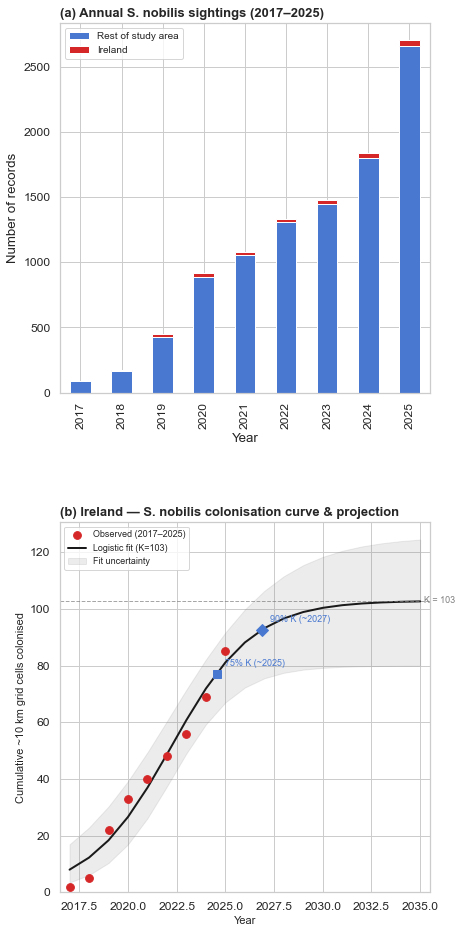

In [ ]:
# ---------- Combined temporal figure: (a) annual sightings + (b) colonisation curve ----------
yearly_plot = yearly[yearly.index <= 2025].copy()
yearly_plot["Rest of study area"] = yearly_plot["All records"] - yearly_plot["Ireland"]

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(8, 16), gridspec_kw={"hspace": 0.35})

# ---- Panel (a): Annual sightings bar chart ----
yearly_plot[["Rest of study area", "Ireland"]].plot.bar(
    stacked=True, color=["#4878d0", "#d62728"], edgecolor="white", ax=ax_a
)
ax_a.set_xlabel("Year")
ax_a.set_ylabel("Number of records")
ax_a.set_title("(a) Annual S. nobilis sightings (2017–2025)", fontsize=13, weight="bold", loc="left")
ax_a.legend(fontsize=10)
ax_a.set_aspect(1.0 / ax_a.get_data_ratio())

# ---- Panel (b): Colonisation curve + logistic projection ----
ax_b.scatter(cum_cells_fit.year, cum_cells_fit.cum_grid_cells, s=60, c="#d62728",
             zorder=5, label="Observed (2017–2025)")

t_proj = np.arange(2017, 2036)
y_proj = logistic(t_proj, *popt)
ax_b.plot(t_proj, y_proj, "k-", lw=2, label=f"Logistic fit (K={K_fit:.0f})")

y_lo = logistic(t_proj, K_fit - perr[0], r_fit + perr[1], t0_fit)
y_hi = logistic(t_proj, K_fit + perr[0], r_fit - perr[1], t0_fit)
ax_b.fill_between(t_proj, y_lo, y_hi, alpha=0.15, color="grey", label="Fit uncertainty")

ax_b.axhline(K_fit, color="grey", ls="--", lw=1, alpha=0.7)
ax_b.text(2035.2, K_fit, f"K = {K_fit:.0f}", va="center", fontsize=9, color="grey")

for pct, marker in [(0.75, "s"), (0.90, "D")]:
    target = pct * K_fit
    yr_est = t0_fit - np.log(K_fit / target - 1) / r_fit
    ax_b.plot(yr_est, target, marker, color="#4878d0", ms=8, zorder=5)
    ax_b.annotate(f"{pct:.0%} K (~{yr_est:.0f})", (yr_est, target),
                  textcoords="offset points", xytext=(8, 8), fontsize=9, color="#4878d0")

ax_b.set_xlabel("Year", fontsize=11)
ax_b.set_ylabel("Cumulative ~10 km grid cells colonised", fontsize=11)
ax_b.set_title("(b) Ireland — S. nobilis colonisation curve & projection",
               fontsize=13, weight="bold", loc="left")
ax_b.legend(fontsize=9)
ax_b.set_xlim(2016.5, 2035.5)
ax_b.set_ylim(0, None)
ax_b.set_aspect(1.0 / ax_b.get_data_ratio())

plt.savefig(f"{OUTPUT_DIR}/temporal_combined.png", dpi=200, bbox_inches="tight")
plt.show()

### 9.4 High-suitability areas not yet colonised

This map highlights the gap between where *S. nobilis* has been recorded and where the model predicts it *could* establish. Orange/red areas with no overlaid point are high-suitability zones with no records to date — these are the most likely candidates for future colonisation. The table below lists specific locations.

In [ ]:
# ---------- Identify high-suitability uncolonised grid cells ----------
# Build a grid of 0.1-deg cells over Ireland, compute mean suitability, flag if colonised

colonised_cells = set(ire["grid_cell"].unique())

grid_data = []
for lat_c in lat_bins + 0.05:
    for lon_c in lon_bins + 0.05:
        row = int((ire_bounds.top - lat_c) / (ire_bounds.top - ire_bounds.bottom) * suit_ireland.shape[0])
        col = int((lon_c - ire_bounds.left) / (ire_bounds.right - ire_bounds.left) * suit_ireland.shape[1])
        if 0 <= row < suit_ireland.shape[0] and 0 <= col < suit_ireland.shape[1]:
            val = suit_ireland[row, col]
            if not np.isnan(val):
                cell_id = f"{int(round(lat_c*10))}_{int(round(lon_c*10))}"
                grid_data.append({
                    "lat": lat_c, "lon": lon_c,
                    "suitability": val,
                    "colonised": cell_id in colonised_cells,
                    "grid_cell": cell_id,
                })

grid_df = pd.DataFrame(grid_data)

# High suitability uncolonised cells
uncolonised_suitable = grid_df[(grid_df.suitability >= 0.4) & (~grid_df.colonised)].sort_values(
    "suitability", ascending=False
)

print(f"Total land grid cells: {len(grid_df)}")
print(f"Colonised: {grid_df.colonised.sum()}")
print(f"High suitability (>= 0.4) & uncolonised: {len(uncolonised_suitable)}")
print(f"\nTop 15 uncolonised high-suitability locations:")
print(uncolonised_suitable[["lat", "lon", "suitability"]].head(15).to_string(index=False))

Total land grid cells: 1101
Colonised: 72
High suitability (>= 0.4) & uncolonised: 34

Top 15 uncolonised high-suitability locations:
  lat   lon  suitability
53.35 -7.25     1.000000
52.25 -7.15     0.999994
53.05 -6.95     0.999984
52.45 -9.05     0.996254
54.65 -6.75     0.994428
53.35 -6.55     0.993204
52.65 -7.25     0.989144
54.35 -6.65     0.948914
52.35 -8.05     0.874745
52.65 -8.65     0.869916
55.05 -6.95     0.828575
53.45 -6.25     0.796853
53.25 -6.95     0.753123
51.75 -8.75     0.739254
53.15 -6.85     0.732612


In [ ]:
# ---------- Map: colonised vs uncolonised suitable cells ----------
fig, ax = plt.subplots(figsize=(8, 10))

# Suitability background — blue-red colourmap, semi-transparent
ax.imshow(
    suit_ireland,
    extent=[ire_bounds.left, ire_bounds.right, ire_bounds.bottom, ire_bounds.top],
    origin="upper", cmap=suit_cmap, vmin=0, vmax=1, interpolation="nearest",
    aspect=ire_aspect, alpha=0.5,
)

# Colonised cells — dark blue with white edges
colonised_df = grid_df[grid_df.colonised]
ax.scatter(colonised_df.lon, colonised_df.lat,
           s=50, c="#eadf09", marker="o", edgecolors="white", linewidths=0.6,
           alpha=0.7, zorder=4, label=f"Colonised (n={len(colonised_df)})")

# Uncolonised high-suitability cells — bright cyan diamonds with black edges
ax.scatter(uncolonised_suitable.lon, uncolonised_suitable.lat,
           s=70, marker="D", c="#00ff1e", edgecolors="black", linewidths=0.8,
           alpha=0.75, zorder=5, label=f"Suitable & uncolonised (n={len(uncolonised_suitable)})")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Ireland — colonised vs high-suitability uncolonised cells",
             fontsize=13, weight="bold")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ireland_uncolonised_suitable.png", dpi=200, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined